In [1]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [2]:
import torch
print(torch.cuda.is_available())  # must be True

True


In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer

ds = load_dataset("stanfordnlp/imdb")
tok = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=256)

train = ds["train"].shuffle(seed=42).select(range(4000)).map(tokenize, batched=True)
test  = ds["test"].shuffle(seed=42).select(range(1000)).map(tokenize, batched=True)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [4]:
import numpy as np, evaluate
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
acc = evaluate.load("accuracy")

def metrics(p):
    return acc.compute(predictions=np.argmax(p.predictions, axis=1), references=p.label_ids)

args = TrainingArguments(
    output_dir="out",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    report_to="none",
    fp16=True,
)

trainer = Trainer(model=model, args=args, train_dataset=train,
                  eval_dataset=test, compute_metrics=metrics)
trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.264199,0.890000
2,0.276499,0.289116,0.894000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.2764986572265625, metrics={'train_runtime': 116.0406, 'train_samples_per_second': 68.941, 'train_steps_per_second': 4.309, 'total_flos': 1052444221440000.0, 'train_loss': 0.2764986572265625, 'epoch': 2.0})

In [5]:
print(trainer.evaluate())

Training Loss,Validation Loss,Epoch,Accuracy
0.276499,0.289116,2,0.894000


{'eval_loss': 0.28911563754081726, 'eval_accuracy': 0.894}


In [6]:
from transformers import pipeline

clf = pipeline("sentiment-analysis", model=model, tokenizer=tok, device=0)
for text in ["I loved this movie, absolutely brilliant!",
             "Total waste of time, awful acting.",
             "The plot was predictable but the acting saved it."]:
    print(text, "->", clf(text))

I loved this movie, absolutely brilliant! -> [{'label': 'LABEL_1', 'score': 0.990767776966095}]
Total waste of time, awful acting. -> [{'label': 'LABEL_0', 'score': 0.9898303151130676}]
The plot was predictable but the acting saved it. -> [{'label': 'LABEL_0', 'score': 0.9325147271156311}]


              precision    recall  f1-score   support

    negative       0.91      0.88      0.89       512
    positive       0.88      0.91      0.89       488

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



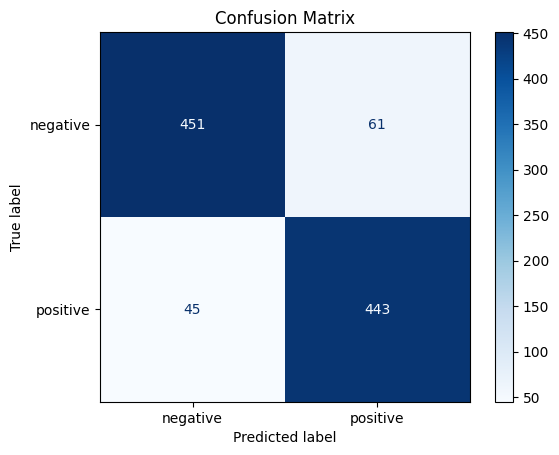

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

out = trainer.predict(test)
preds = np.argmax(out.predictions, axis=1)
labels = out.label_ids

print(classification_report(labels, preds, target_names=["negative", "positive"]))

ConfusionMatrixDisplay(confusion_matrix(labels, preds),
                       display_labels=["negative", "positive"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()